# **SEO Underwriting Fee Analysis**

This project analyzes the drivers of underwriting fees for seasoned equity offerings (SEOs) in the United States. Using regression, forecasting, and decision tree methods, the analysis identifies the main factors associated with fee levels and estimates near-term average fees.

## 1. Project Objective

- What factors influence SEO underwriting fees?
- Do larger firms and larger issues receive lower fees?
- What are the expected average fee levels for 2026–2027?
- Which variables matter most in predicting fees?

## 2. Import Libraries

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import os
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Data Loading

The analysis uses a U.S. seasoned equity offering dataset with approximately 17,500 transactions.

Key variables include:
- Underwriting fees
- Issue size
- Post-offering market value
- Offer price
- Exchange
- Industry
- Year

In [8]:
sdc = pd.read_excel("SDC.xlsx")
print(sdc.head())
print(sdc.dtypes)

    CUSIP  MASTER_DEAL_NO                       NINAMES  PRINCIPALAMOUNT  \
0  580037      1099117009   McDermott International Inc           15.375   
1  860342      1099118009  Stewart & Stevenson Services           10.600   
2  42221H      1099120009  HealthTrust Inc-The Hospital           49.000   
3  464330      1099133009      Isis Pharmaceuticals Inc            2.500   
4  204932      1099139009                   CompUSA Inc           18.182   

   EXCHANGE          INDUSTRY  MKTVALUEPF  industry_code  year  fees  \
0  New York  Pers/Bus/Rep Svc      1141.5              8  1995  0.75   
1    Nasdaq     Manufacturing       850.9              3  1995  2.12   
2  New York        Healthcare         NaN              8  1995  0.77   
3    Nasdaq     Manufacturing         NaN              2  1995  0.75   
4  New York            Retail       201.1              5  1995  1.00   

   offer_price  
0       15.375  
1       53.000  
2       14.000  
3       12.500  
4       15.000  
CUSIP   

## 4. Data Preparation

- Standardized column names
- Converted financial variables to numeric types
- Removed duplicates
- Removed missing fee observations
- Applied winsorization to reduce outlier influence
- Created log-transformed financial variables
- Converted exchange, industry, and year to categorical variables

In [9]:
# Winsorize a numeric Series at given quantiles (returns Series, and cutpoints)
def winsorize_series(s: pd.Series, lower=0.01, upper=0.99):
    q_low, q_hi = s.quantile(lower), s.quantile(upper)
    s_w = s.clip(lower=q_low, upper=q_hi)
    return s_w, float(q_low), float(q_hi)

# Standardize column names: strip, lower, replace spaces with underscores
sdc.columns = (
    sdc.columns.str.strip()
               .str.lower()
               .str.replace(r"\s+", "_", regex=True)
)

# Trim whitespace in object columns
for c in sdc.select_dtypes(include="object"):
    sdc[c] = sdc[c].astype(str).str.strip()

# Convert key columns to numeric
numeric_cols = ["principalamount", "mktvaluepf", "offer_price", "fees", "industry_code", "year"]
for c in numeric_cols:
    if c in sdc.columns:
        sdc[c] = pd.to_numeric(sdc[c], errors="coerce")

# Remove duplicates
before = len(sdc)
sdc = sdc.drop_duplicates()
after_exact = len(sdc)

# If master_deal_no exists, keep first occurrence
if "master_deal_no" in sdc.columns:
    before_key = len(sdc)
    sdc = sdc.sort_values(["master_deal_no"]).drop_duplicates(subset=["master_deal_no"], keep="first")
    after_key = len(sdc)
else:
    before_key = after_key = len(sdc)

print(f"Rows before: {before:,}")
print(f"Removed exact dups: {before - after_exact:,}")
print(f"Removed dups on master_deal_no: {before_key - after_key:,}")
print(f"Rows after dedupe: {len(sdc):,}")

# Drop rows with missing FEES
before_na = len(sdc)
sdc = sdc.dropna(subset=["fees"])
print(f"Dropped rows with missing FEES: {before_na - len(sdc):,}")

# Outliers handling (winsorize key numerics)
winsor_summary = {}
for c in ["fees", "principalamount", "mktvaluepf", "offer_price"]:
    if c in sdc.columns:
        sdc[c], ql, qh = winsorize_series(sdc[c], 0.01, 0.99)
        winsor_summary[c] = {"q01": ql, "q99": qh}

# Create log-transforms
for base in ["fees", "principalamount", "mktvaluepf", "offer_price"]:
    if base in sdc.columns:
        sdc[f"log_{base}"] = np.log(sdc[base])

winsor_summary

# Categorical encodings
for c in ["industry_code", "year", "exchange"]:
    if c in sdc.columns:
        sdc[c] = sdc[c].astype("category")

# Create local output folder
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

# Define file paths
excel_path = os.path.join(output_dir, "cleaned_SDC.xlsx")

# Save dataset locally
sdc.to_csv(excel_path, index=False)

print(f"Dataset saved to: {excel_path}")
print("Final dataset shape:", sdc.shape)

sdc.head()

Rows before: 17,496
Removed exact dups: 0
Removed dups on master_deal_no: 0
Rows after dedupe: 17,496
Dropped rows with missing FEES: 3,926
Dataset saved to: data/cleaned_SDC.xlsx
Final dataset shape: (13570, 15)


,cusip,master_deal_no,ninames,principalamount,exchange,industry,mktvaluepf,industry_code,year,fees,offer_price,log_fees,log_principalamount,log_mktvaluepf,log_offer_price
98,566140,185697002,Marcam Corp,31.50,Nasdaq,Pers/Bus/Rep Svc,130.1,7,1995,5.524,21.00,1.709102,3.449988,4.868303,3.044522
99,462218,186342002,Ionics Inc,32.55,New York,Manufacturing,175.7,3,1995,4.516,31.00,1.507627,3.482777,5.168778,3.433987
100,001765,186493002,AMR Corp,210.00,New York,Transportation,3572.6,4,1995,2.000,52.50,0.693147,5.347108,8.181049,3.960813
101,873168,187198002,Texas Utilities Co,217.50,New York,Electric Service,NaN,4,1995,2.455,36.25,0.898127,5.382199,NaN,3.590439
102,938815,192153002,Washington Energy Co,42.75,Nasdaq,Gas Distribution,357.0,4,1995,3.789,19.00,1.332102,3.755369,5.877736,2.944439


## 5. Exploratory Analysis

### Key Patterns in the Data

- The average underwriting fee is approximately **4.68%**, with most observations falling between **3.9% and 6.0%**, indicating relatively stable pricing across deals.

- Fee distribution is slightly left-skewed, with a small number of high-fee outliers (up to ~9.5%), suggesting that extreme pricing occurs but is not common.

- Financial variables such as **issue size (principal amount)** and **market value** are highly right-skewed, reflecting large variation between small and very large firms.

---

### Industry Distribution

- The dataset is dominated by a few industries:
  - **Manufacturing (~35%)** is the largest segment  
  - Followed by **Personal/Business/Repair Services (~14%)** and **REIT (~11%)**  
- A significant portion (**~30%**) falls into “Other”, indicating broad industry coverage.

---

### Relationship Between Fees and Firm Size

- There is a strong negative relationship between **market value and underwriting fees** (**correlation ≈ -0.67**).

- Larger firms tend to pay **lower percentage fees**, suggesting economies of scale in underwriting.

- The relationship is non-linear:
  - Fees decline more sharply for smaller firms  
  - The effect flattens for very large firms  

---

### Key Insight

- Overall, the exploratory analysis suggests that **firm size is a major driver of underwriting fees**, with larger firms consistently benefiting from lower costs of issuance.

In [10]:
# Descriptive Statistics of numerical values
num_cols = ["fees","principalamount","mktvaluepf","offer_price"]
desc = sdc[num_cols].describe().T  # mean, std, min, 25%, 50%, 75%, max
desc["skew"] = sdc[num_cols].skew()
desc["kurtosis"] = sdc[num_cols].kurt()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
fees,13570.0,4.682,1.720,0.329,3.882,5.00,6.00,9.500,-0.487,0.548
principalamount,13570.0,153.394,240.732,1.967,30.000,70.95,162.00,1493.381,3.426,13.471
mktvaluepf,13015.0,2227.167,4847.975,11.528,227.150,653.40,1878.85,32713.588,4.365,21.229
offer_price,13570.0,25.571,22.775,0.600,10.750,20.50,32.50,135.000,2.208,6.593


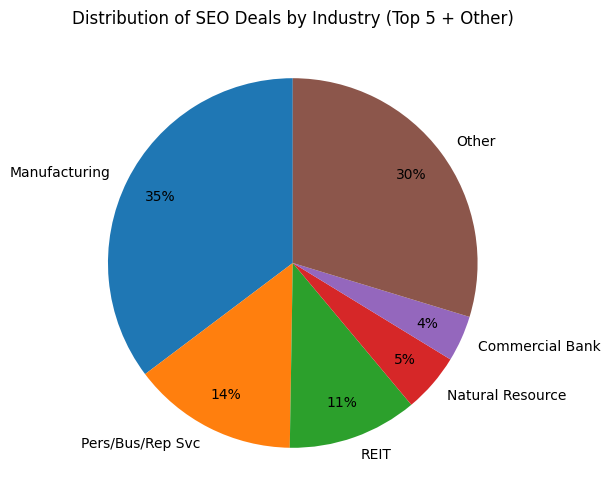

In [12]:
# Pie Chart: Distribution of SEO Deals by Industry (Top 5 + Others)
industry_counts = sdc["industry"].value_counts()
top5 = industry_counts.nlargest(5)
other_sum = industry_counts.iloc[5:].sum()
pie_data = top5.copy()
pie_data["Other"] = other_sum
plt.figure(figsize=(6,6))
pie_data.plot(kind="pie", autopct="%1.0f%%", startangle=90, pctdistance=0.8)
plt.ylabel("")  # remove default y-label
plt.title("Distribution of SEO Deals by Industry (Top 5 + Other)")
plt.show()

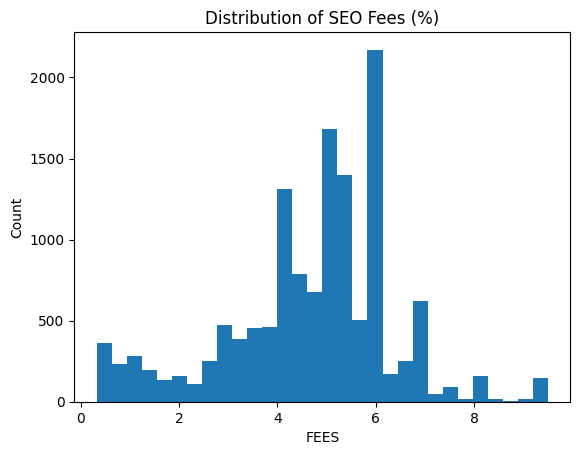

In [14]:
# Histogram: Distribution of SEO Fees
sdc["fees"].plot(kind="hist", bins=30)
plt.title("Distribution of SEO Fees (%)")
plt.xlabel("FEES")
plt.ylabel("Count")
plt.show()

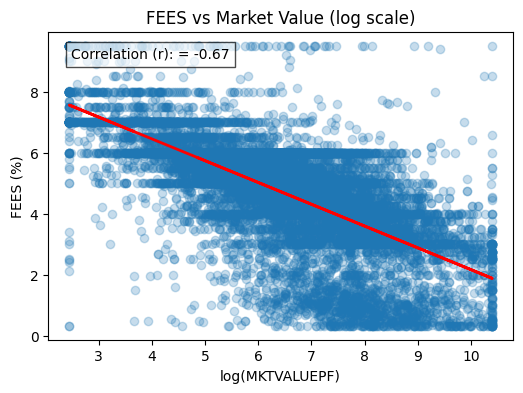

In [18]:
# Scatter plot (FEES vs MARKETVALUE) with trend line + correlation

x = np.log(sdc["mktvaluepf"])
y = sdc["fees"]

# Create a DataFrame to easily drop NaNs from both x and y
df_plot = pd.DataFrame({"x": x, "y": y}).dropna()
x_clean = df_plot["x"]
y_clean = df_plot["y"]

# Calculate correlation with clean data
corr = np.corrcoef(x_clean, y_clean)[0, 1]

plt.figure(figsize=(6,4))
plt.scatter(x_clean, y_clean, alpha=0.25)

# Best-fit line with clean data
m, b = np.polyfit(x_clean, y_clean, 1)
plt.plot(x_clean, m*x_clean + b, linewidth=2, color="red")

# Labels
plt.xlabel("log(MKTVALUEPF)")
plt.ylabel("FEES (%)")
plt.title("FEES vs Market Value (log scale)")

# Add correlation text inside plot
plt.text(
    0.05, 0.95,
    f"Correlation (r): = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.show()

## 6. Regression Modelling

To identify the key drivers of SEO underwriting fees, multiple regression models were estimated.

### Model Specification

- Dependent variable: **Underwriting fees (%)**
- Key independent variables:
  - Log of market value
  - Log of issue size (principal amount)
  - Offer price
- Control variables:
  - Exchange (categorical)
  - Industry (categorical)
  - Year (categorical)

### Key Results

- **Market value** has a strong negative relationship with underwriting fees  
  → Larger firms tend to pay lower fees  

- **Issue size** is also negatively associated with fees  
  → Larger deals benefit from lower percentage costs  

- **Offer price** shows a weaker effect compared to size-related variables  

- The model explains a substantial portion of variation in fees (**R² ≈ 0.5**)

### Interpretation

The results suggest strong **economies of scale** in underwriting:
- Larger firms and larger offerings face lower relative issuance costs  
- Smaller firms pay a premium, likely due to higher risk and fixed underwriting costs

In [19]:
# Three OLS regressions
for base in ["fees","principalamount","mktvaluepf","offer_price"]:
    if f"log_{base}" not in sdc.columns and base in sdc.columns and (sdc[base] > 0).all():
        sdc[f"log_{base}"] = np.log(sdc[base])

# Model A (baseline, logs + exchange FE)
formula_A = "fees ~ log_principalamount + log_mktvaluepf + log_offer_price + C(exchange) + C(year) + C(industry_code)"

# Model B (levels for price, add OFFER_PRICE level, keep logs for size/cap)
formula_B = "fees ~ log_principalamount + log_mktvaluepf + offer_price + C(exchange) + C(year) + C(industry_code)"

# Model C (add interaction size×cap to check scale effects)
formula_C = "fees ~ log_principalamount + log_mktvaluepf + log_principalamount:log_mktvaluepf + C(exchange) + C(year) + C(industry_code)"

models = {}
for name, fml in {"Model_A":formula_A,"Model_B":formula_B,"Model_C":formula_C}.items():
    mod = smf.ols(fml, data=sdc).fit(cov_type="HC3")
    models[name] = mod

# Side-by-side table for the report
from statsmodels.iolib.summary2 import summary_col
table = summary_col(results=list(models.values()),
                    float_format="%.3f",
                    stars=True, model_names=list(models.keys()),
                    info_dict={'N':lambda x: f"{int(x.nobs)}"})
print(table)


                                    Model_A   Model_B   Model_C 
----------------------------------------------------------------
Intercept                          8.997***  8.912***  8.876*** 
                                   (0.181)   (0.184)   (0.216)  
C(exchange)[T.New York]            -0.587*** -0.574*** -0.566***
                                   (0.028)   (0.028)   (0.028)  
C(year)[T.1996]                    0.176**   0.185**   0.189**  
                                   (0.079)   (0.080)   (0.081)  
C(year)[T.1997]                    0.186***  0.186**   0.185**  
                                   (0.071)   (0.072)   (0.073)  
C(year)[T.1998]                    0.159**   0.159**   0.159*   
                                   (0.079)   (0.080)   (0.081)  
C(year)[T.1999]                    0.183**   0.182**   0.182**  
                                   (0.071)   (0.072)   (0.073)  
C(year)[T.2000]                    0.231***  0.232***  0.231*** 
                        

## 7. Forecasting SEO Fees

Average underwriting fees were aggregated by year and modeled using an AR process.

Two models (AR(1) and AR(2)) were compared using AIC. The AR(1) model was selected due to better model fit.

Forecasts for 2026–2027 suggest stable fee levels around 4.8%–5.0%.

### Interpretation

- Underwriting fees show **strong persistence over time**
- No major structural shift is expected in the near term  
- Market conditions appear relatively stable based on historical patterns

In [24]:
# Aggregate to yearly average fees
ts = sdc.groupby("year")["fees"].mean()

# Compare AR models
model_ar1 = sm.tsa.ARIMA(ts, order=(1,0,0)).fit()
model_ar2 = sm.tsa.ARIMA(ts, order=(2,0,0)).fit()

print("AR(1) AIC:", model_ar1.aic)
print("AR(2) AIC:", model_ar2.aic)

# Final model
model = sm.tsa.ARIMA(ts, order=(1,0,0)).fit()

# Forecast next 2 years
forecast = model.forecast(steps=2)
forecast

AR(1) AIC: -2.5067719978292207
AR(2) AIC: -1.5396373666175442


/tmp/ipykernel_1330/3983272336.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ts = sdc.groupby("year")["fees"].mean()
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provi

,predicted_mean
31,4.854068
32,4.798925


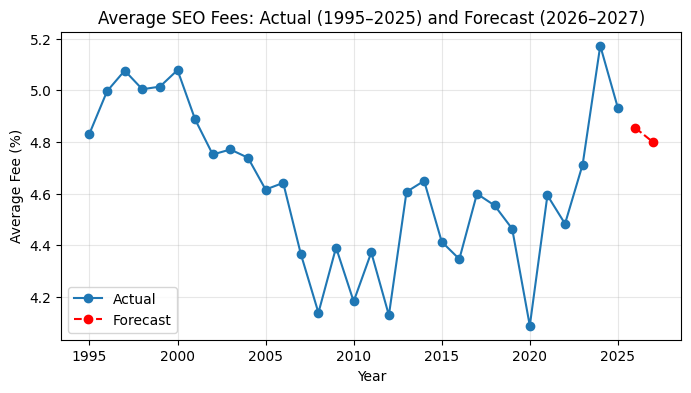

In [25]:
# Convert forecast index to real years:
years_forecast = np.array([2026, 2027])
values_forecast = forecast.values

# Time series plot of actual and predicted values for 1995-2027 period
plt.figure(figsize=(8,4))
plt.plot(ts.index, ts.values, label="Actual", marker='o')
plt.plot(years_forecast, values_forecast, label="Forecast", marker='o', linestyle='--', color='red')
plt.title("Average SEO Fees: Actual (1995–2025) and Forecast (2026–2027)")
plt.xlabel("Year")
plt.ylabel("Average Fee (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Variable Importance

A decision tree model was used to assess the relative importance of different predictors.

### Key Result

- **Market value** is the most important variable in predicting underwriting fees  
- Followed by:
  - Issue size  
  - Other deal characteristics  

### Interpretation

- Firm size is the dominant factor influencing underwriting costs  
- This reinforces regression results and confirms robustness across methods  


Tree_depth3 Variable Importance:
 mktvaluepf         0.987246
industry_code      0.012754
principalamount    0.000000
offer_price        0.000000
year               0.000000
dtype: float64

Tree_depth5 Variable Importance:
 mktvaluepf         0.868545
year               0.053526
industry_code      0.042110
offer_price        0.025691
principalamount    0.010128
dtype: float64

Tree_full Variable Importance:
 mktvaluepf         0.554436
principalamount    0.131085
offer_price        0.126445
year               0.118154
industry_code      0.069880
dtype: float64


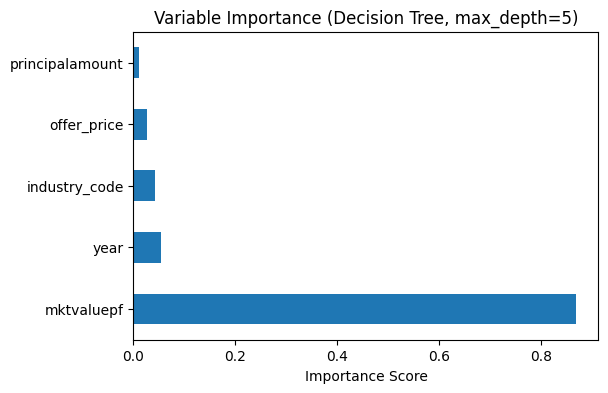

In [26]:
# Select variables for decision tree
vars_tree = ["fees", "principalamount", "mktvaluepf", "offer_price", "industry_code", "year"]

tree_sdc = sdc[vars_tree].dropna()  # drop rows with empty value

# Ensure numeric dtype
tree_sdc["industry_code"] = tree_sdc["industry_code"].astype(int)
tree_sdc["year"] = tree_sdc["year"].astype(int)

# Train Three Decision Tree Models
from sklearn.tree import DecisionTreeRegressor

X = tree_sdc.drop(columns=["fees"])
y = tree_sdc["fees"]

models_tree = {
    "Tree_depth3": DecisionTreeRegressor(max_depth=3, random_state=42),
    "Tree_depth5": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Tree_full":   DecisionTreeRegressor(random_state=42)
}

for name, model in models_tree.items():
    model.fit(X, y)

# Extract and compare variables' level of importance
importance_tables = {}

for name, model in models_tree.items():
    importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    importance_tables[name] = importance
    print(f"\n{name} Variable Importance:\n", importance)

importance = importance_tables["Tree_depth5"]  # choose mid-complexity model

plt.figure(figsize=(6,4))
importance.plot(kind='barh')
plt.title("Variable Importance (Decision Tree, max_depth=5)")
plt.xlabel("Importance Score")
plt.show()

## 9. Key Findings

- Larger firms tend to pay lower underwriting fees.
- Larger issue sizes are also associated with lower percentage fees.
- Forecasted average SEO fees remain broadly stable at around 4.8%–5.0% for 2026–2027.
- Market value is the most important predictor of underwriting fees in the decision tree model.

## 10. Limitations

- Results are based on historical U.S. SEO transactions and may not generalize to all markets.
- Some variation in fees may be driven by factors not included in the model.
- Forecasts assume similar market conditions to the historical sample.